In [2]:
pwd

'/content'

In [3]:
!git clone https://github.com/neverthesameagain/ACEhack

fatal: destination path 'ACEhack' already exists and is not an empty directory.


In [4]:
cd ACEhack

/content/ACEhack


In [5]:
!git fetch --all

Fetching origin


In [6]:
!git checkout -b option-b-text-injection

fatal: A branch named 'option-b-text-injection' already exists.


In [7]:
!git pull origin option-b-text-injection

From https://github.com/neverthesameagain/ACEhack
 * branch            option-b-text-injection -> FETCH_HEAD
Already up to date.


# EIE Economic Intelligence Engine Experimental Narrative



1. Agents learn.
2. Behavior emerges.
3. The LLM policy is trained to replicate and improve this behavior.

This notebook is intentionally split into two phases:

- **Phase 1: Agent-Level Training** using the existing environment learning system: Q-values, trust dynamics, memory updates, and opponent modeling.
- **Phase 2: LLM Policy Training** using lightweight GRPO as an advanced extension.

We do **not** start with LLM training. First we prove the environment itself supports adaptive strategic behavior.

In [8]:
import copy
import json
import os
import random
import statistics
import sys
from collections import Counter, defaultdict
from pathlib import Path

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ace_reward import ACTIONS
from ace_world_env import ACEWorldEnv
from ace_llm_policy import (
    build_action_prompt,
    extract_first_valid_json,
    generate_action,
    llm_policy,
    normalize_action,
)

RNG = random.Random(42)
COOP_ACTIONS = {"propose_alliance", "accept_alliance", "execute_contract"}
BETRAY_ACTIONS = {"betray"}
AGGRESSIVE_ACTIONS = {"challenge", "betray", "submit_bid"}

print('EIE environment loaded')

EIE environment loaded


# Phase 1 — Agent-Level Training (Primary)

## Objective

Demonstrate that agents learn from rewards, adapt strategies, and change behavior over time.

This phase uses the existing environment learning system:

- Q-value updates
- trust dynamics
- memory updates
- opponent modeling

This is reinforcement learning at the agent level, similar to tabular RL / policy adaptation. It is not deep PPO.

## Phase 1 Method

We run repeated environment episodes. During each round:

1. The world produces a hidden regime: `competitive`, `cooperative`, or `resource`.
2. Agents receive noisy observations.
3. Agents choose actions using their fallback policy.
4. Rewards are computed by the environment.
5. Agents update memory, trust, opponent models, strategy success counters, and Q-values.

This tests whether strategic behavior emerges from repeated rewards and interactions.

In [9]:
def random_action(agent, env):
    action = RNG.choice(list(ACTIONS))
    params = {}
    other_ids = [a.agent_id for a in env.agents if a.agent_id != agent.agent_id]
    if other_ids and action in {"propose_alliance", "accept_alliance", "betray", "challenge"}:
        params["target"] = RNG.choice(other_ids)
    if action in {"submit_bid", "allocate_resources"}:
        params["amount"] = RNG.randint(10, 100)
    return {
        "predicted_round": RNG.choice(["competitive", "cooperative", "resource"]),
        "action": action,
        "parameters": params,
        "reasoning": "random pre-learning baseline",
    }


def mean_trust(env):
    vals = []
    for agent in env.agents:
        vals.extend(agent.trust_scores.values())
    return statistics.mean(vals) if vals else 0.5


def flatten_round(result, env, episode, phase, scenario):
    rows = []
    for item in result["results"]:
        action = item["action"]["action"]
        agent = item["agent"]
        rows.append({
            "episode": episode,
            "phase": phase,
            "scenario": scenario,
            "agent": agent.name,
            "action": action,
            "reward": float(item["reward"]["total"]),
            "ground_truth": result["ground_truth"],
            "cooperation": int(action in COOP_ACTIONS),
            "betrayal": int(action in BETRAY_ACTIONS),
            "aggression": int(action in AGGRESSIVE_ACTIONS),
            "avg_trust": mean_trust(env),
            "resources": float(item["resources"]),
        })
    return rows


def run_agent_learning(event_text, episodes=30, random_baseline_episodes=6, seed=100, scenario="general"):
    env = ACEWorldEnv(rng_seed=seed)
    env.apply_event(event_text)
    rows = []

    # Before learning: deliberately random actions to show unstable pre-learning behavior.
    for episode in range(random_baseline_episodes):
        actions = [random_action(agent, env) for agent in env.agents]
        result = env.step(actions)
        rows.extend(flatten_round(result, env, episode, "before_random", scenario))

    # After learning starts: use the environment's adaptive policy and update loop.
    for episode in range(random_baseline_episodes, episodes):
        result = env.step()
        rows.extend(flatten_round(result, env, episode, "after_learning", scenario))

    return env, rows


oil_env, oil_rows = run_agent_learning(
    "Oil crisis disrupts shipping, raises energy costs, and increases geopolitical risk",
    episodes=32,
    random_baseline_episodes=6,
    seed=201,
    scenario="oil_crisis",
)
peace_env, peace_rows = run_agent_learning(
    "Peace agreement lowers trade tension, improves cooperation, and stabilizes supply chains",
    episodes=32,
    random_baseline_episodes=6,
    seed=202,
    scenario="peace_scenario",
)
all_phase1_rows = oil_rows + peace_rows
print('phase 1 rows:', len(all_phase1_rows))
print('oil final regime:', oil_env.world.economic_regime())
print('peace final regime:', peace_env.world.economic_regime())

phase 1 rows: 448
oil final regime: crisis
peace final regime: recession


## Phase 1 Quantitative Analysis

Mandatory metrics:

1. Reward vs Episodes
2. Cooperation Rate vs Episodes
3. Betrayal Rate vs Episodes
4. Trust Evolution

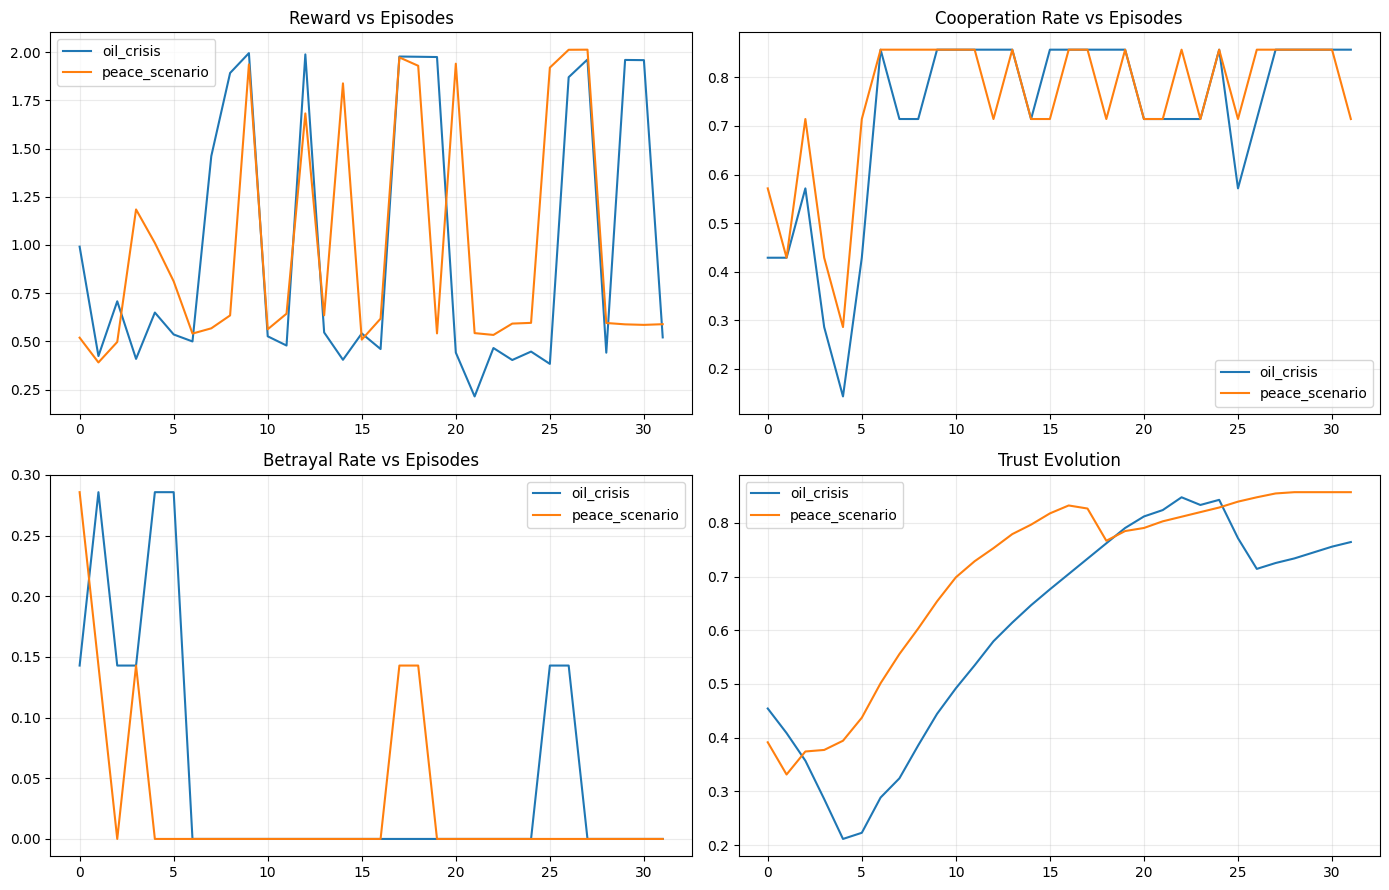

[{'scenario': 'peace_scenario',
  'episode': 27,
  'reward': 2.0124497583100265,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.0,
  'avg_trust': 0.8547619047619048,
  'aggression': 0.14285714285714285},
 {'scenario': 'peace_scenario',
  'episode': 28,
  'reward': 0.5957242849844282,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.0,
  'avg_trust': 0.8571428571428571,
  'aggression': 0.14285714285714285},
 {'scenario': 'peace_scenario',
  'episode': 29,
  'reward': 0.5886542251496769,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.0,
  'avg_trust': 0.8571428571428571,
  'aggression': 0.14285714285714285},
 {'scenario': 'peace_scenario',
  'episode': 30,
  'reward': 0.5859544960529869,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.0,
  'avg_trust': 0.8571428571428571,
  'aggression': 0.14285714285714285},
 {'scenario': 'peace_scenario',
  'episode': 31,
  'reward': 0.5894262481836565,
  'cooperation': 0.7142857142857143,
  'betrayal': 0.0,
  'avg_trust': 0.857142

In [10]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

phase1 = all_phase1_rows


def grouped_mean(rows, keys, fields):
    buckets = {}
    for row in rows:
        key = tuple(row[k] for k in keys)
        if key not in buckets:
            buckets[key] = {field: [] for field in fields}
        for field in fields:
            buckets[key][field].append(float(row[field]))
    out = []
    for key, vals in buckets.items():
        item = {keys[i]: key[i] for i in range(len(keys))}
        for field, numbers in vals.items():
            item[field] = statistics.mean(numbers) if numbers else 0.0
        out.append(item)
    return sorted(out, key=lambda x: tuple(x[k] for k in keys))


def action_counts(rows, keys):
    counts = Counter(tuple(row[k] for k in keys) for row in rows)
    out = []
    for key, count in counts.items():
        item = {keys[i]: key[i] for i in range(len(keys))}
        item['count'] = count
        out.append(item)
    return sorted(out, key=lambda x: tuple(x[k] for k in keys))

summary = grouped_mean(phase1, ['scenario', 'episode'], ['reward', 'cooperation', 'betrayal', 'avg_trust', 'aggression'])

if plt is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for scenario in sorted({row['scenario'] for row in summary}):
        group = [row for row in summary if row['scenario'] == scenario]
        episodes = [row['episode'] for row in group]
        axes[0, 0].plot(episodes, [row['reward'] for row in group], label=scenario)
        axes[0, 1].plot(episodes, [row['cooperation'] for row in group], label=scenario)
        axes[1, 0].plot(episodes, [row['betrayal'] for row in group], label=scenario)
        axes[1, 1].plot(episodes, [row['avg_trust'] for row in group], label=scenario)

    axes[0, 0].set_title('Reward vs Episodes')
    axes[0, 1].set_title('Cooperation Rate vs Episodes')
    axes[1, 0].set_title('Betrayal Rate vs Episodes')
    axes[1, 1].set_title('Trust Evolution')
    for ax in axes.flatten():
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()

else:
    print('matplotlib not installed; computed summary series for required plots.')
    for row in summary[:8]:
        print(row)

summary[-5:]

## Phase 1 Before vs After Summary

We compare the random pre-learning window with the later adaptive window. The expected pattern is not that every metric monotonically improves. The important pattern is regime-dependent adaptation:

- Oil crisis should push agents toward more aggressive or defensive behavior.
- Peace scenario should push agents toward cooperation.
- Trust should respond to repeated social outcomes.

In [11]:
phase_compare = grouped_mean(
    phase1,
    ['scenario', 'phase'],
    ['reward', 'cooperation', 'betrayal', 'aggression', 'avg_trust'],
)
phase_compare

[{'scenario': 'oil_crisis',
  'phase': 'after_learning',
  'reward': 1.0688797241705863,
  'cooperation': 0.8021978021978022,
  'betrayal': 0.01098901098901099,
  'aggression': 0.1813186813186813,
  'avg_trust': 0.6671428571428571},
 {'scenario': 'oil_crisis',
  'phase': 'before_random',
  'reward': 0.6199222071881846,
  'cooperation': 0.38095238095238093,
  'betrayal': 0.21428571428571427,
  'aggression': 0.42857142857142855,
  'avg_trust': 0.3233333333333334},
 {'scenario': 'peace_scenario',
  'phase': 'after_learning',
  'reward': 1.0431774906269935,
  'cooperation': 0.8076923076923077,
  'betrayal': 0.01098901098901099,
  'aggression': 0.17032967032967034,
  'avg_trust': 0.773919413919414},
 {'scenario': 'peace_scenario',
  'phase': 'before_random',
  'reward': 0.7357550120090087,
  'cooperation': 0.5238095238095238,
  'betrayal': 0.09523809523809523,
  'aggression': 0.23809523809523808,
  'avg_trust': 0.38428571428571434}]

## Case Study 1 — Oil Crisis

**Before learning:** agents begin with random behavior. Some cooperate, some bid, some betray, and some challenge without a coherent strategy.

**After learning:** the oil shock raises energy costs, scarcity pressure, and volatility. Agents increasingly favor aggressive or defensive strategies such as `challenge`, `submit_bid`, and `allocate_resources` when those actions receive better rewards.

Interpretation: agents learn regime-dependent strategies. In a crisis, cooperation is not always optimal; exposed agents adapt toward competition and resource protection.

In [12]:
oil_case = [row for row in phase1 if row['scenario'] == 'oil_crisis']
oil_actions = action_counts(oil_case, ['phase', 'action'])
oil_metrics = grouped_mean(oil_case, ['phase'], ['reward', 'aggression', 'cooperation', 'betrayal'])
print(oil_metrics)
sorted(oil_actions, key=lambda x: (x['phase'], -x['count']))[:20]

[{'phase': 'after_learning', 'reward': 1.0688797241705863, 'aggression': 0.1813186813186813, 'cooperation': 0.8021978021978022, 'betrayal': 0.01098901098901099}, {'phase': 'before_random', 'reward': 0.6199222071881846, 'aggression': 0.42857142857142855, 'cooperation': 0.38095238095238093, 'betrayal': 0.21428571428571427}]


[{'phase': 'after_learning', 'action': 'propose_alliance', 'count': 75},
 {'phase': 'after_learning', 'action': 'execute_contract', 'count': 71},
 {'phase': 'after_learning', 'action': 'submit_bid', 'count': 28},
 {'phase': 'after_learning', 'action': 'allocate_resources', 'count': 3},
 {'phase': 'after_learning', 'action': 'challenge', 'count': 3},
 {'phase': 'after_learning', 'action': 'betray', 'count': 2},
 {'phase': 'before_random', 'action': 'betray', 'count': 9},
 {'phase': 'before_random', 'action': 'propose_alliance', 'count': 8},
 {'phase': 'before_random', 'action': 'challenge', 'count': 6},
 {'phase': 'before_random', 'action': 'execute_contract', 'count': 5},
 {'phase': 'before_random', 'action': 'allocate_resources', 'count': 4},
 {'phase': 'before_random', 'action': 'reject_alliance', 'count': 4},
 {'phase': 'before_random', 'action': 'accept_alliance', 'count': 3},
 {'phase': 'before_random', 'action': 'submit_bid', 'count': 3}]

## Case Study 2 — Peace Scenario

**Before learning:** random actions create unnecessary competition even though the world is becoming more cooperative.

**After learning:** lower geopolitical risk and higher cooperation index make alliances and contracts more attractive. Agents learn that cooperative actions are rewarded more reliably.

Interpretation: trust affects cooperation. When the world supports cooperation and agents repeatedly observe stable outcomes, cooperative behavior emerges.

In [13]:
peace_case = [row for row in phase1 if row['scenario'] == 'peace_scenario']
peace_actions = action_counts(peace_case, ['phase', 'action'])
peace_metrics = grouped_mean(peace_case, ['phase'], ['reward', 'aggression', 'cooperation', 'betrayal'])
print(peace_metrics)
sorted(peace_actions, key=lambda x: (x['phase'], -x['count']))[:20]

[{'phase': 'after_learning', 'reward': 1.0431774906269935, 'aggression': 0.17032967032967034, 'cooperation': 0.8076923076923077, 'betrayal': 0.01098901098901099}, {'phase': 'before_random', 'reward': 0.7357550120090087, 'aggression': 0.23809523809523808, 'cooperation': 0.5238095238095238, 'betrayal': 0.09523809523809523}]


[{'phase': 'after_learning', 'action': 'propose_alliance', 'count': 75},
 {'phase': 'after_learning', 'action': 'execute_contract', 'count': 72},
 {'phase': 'after_learning', 'action': 'submit_bid', 'count': 29},
 {'phase': 'after_learning', 'action': 'allocate_resources', 'count': 4},
 {'phase': 'after_learning', 'action': 'betray', 'count': 2},
 {'phase': 'before_random', 'action': 'propose_alliance', 'count': 9},
 {'phase': 'before_random', 'action': 'reject_alliance', 'count': 9},
 {'phase': 'before_random', 'action': 'execute_contract', 'count': 8},
 {'phase': 'before_random', 'action': 'accept_alliance', 'count': 5},
 {'phase': 'before_random', 'action': 'betray', 'count': 4},
 {'phase': 'before_random', 'action': 'submit_bid', 'count': 4},
 {'phase': 'before_random', 'action': 'challenge', 'count': 2},
 {'phase': 'before_random', 'action': 'allocate_resources', 'count': 1}]

## Case Study 3 — Repeated Interaction

This case forces a specific social sequence:

1. Agent 0 proposes an alliance.
2. Agent 1 accepts.
3. Agent 0 betrays Agent 1.
4. Trust drops.
5. Later rounds adapt to the changed relationship.

Interpretation: repeated interactions lead to stable behavior because agents remember social outcomes and adjust trust/opponent models.

In [14]:
def fallback_action(agent, env):
    return agent.choose_fallback_action(
        env.world.derive_round_probabilities(),
        env.round_number + 1,
        [a.agent_id for a in env.agents],
    )


def run_repeated_interaction_case():
    env = ACEWorldEnv(rng_seed=303)
    env.apply_event('Peace agreement creates room for alliances, but firms still face strategic temptation')
    rows = []

    scripted = [
        {'predicted_round': 'cooperative', 'action': 'propose_alliance', 'parameters': {'target': 1}, 'reasoning': 'open alliance'},
        {'predicted_round': 'cooperative', 'action': 'accept_alliance', 'parameters': {'target': 0}, 'reasoning': 'accept alliance'},
        {'predicted_round': 'competitive', 'action': 'betray', 'parameters': {'target': 1}, 'reasoning': 'exploit partner'},
    ]

    for idx, first_action in enumerate(scripted):
        actions = [first_action]
        for agent in env.agents[1:]:
            actions.append(fallback_action(agent, env))
        result = env.step(actions)
        new_rows = flatten_round(result, env, idx, 'scripted_social_sequence', 'repeated_interaction')
        for row in new_rows:
            row['trust_0_to_1'] = env.agents[0].trust_scores.get(1)
            row['trust_1_to_0'] = env.agents[1].trust_scores.get(0)
        rows.extend(new_rows)

    for episode in range(3, 14):
        result = env.step()
        new_rows = flatten_round(result, env, episode, 'post_betrayal_adaptation', 'repeated_interaction')
        for row in new_rows:
            row['trust_0_to_1'] = env.agents[0].trust_scores.get(1)
            row['trust_1_to_0'] = env.agents[1].trust_scores.get(0)
        rows.extend(new_rows)

    return env, rows

interaction_env, interaction_case = run_repeated_interaction_case()
trust_trace = []
seen = set()
for row in interaction_case:
    if row.get('trust_0_to_1') is None or row.get('trust_1_to_0') is None:
        continue
    key = row['episode']
    if key in seen:
        continue
    seen.add(key)
    trust_trace.append({
        'episode': row['episode'],
        'phase': row['phase'],
        'trust_0_to_1': row['trust_0_to_1'],
        'trust_1_to_0': row['trust_1_to_0'],
    })
trust_trace

[{'episode': 0,
  'phase': 'scripted_social_sequence',
  'trust_0_to_1': 0.6599999999999999,
  'trust_1_to_0': 0.6599999999999999},
 {'episode': 1,
  'phase': 'scripted_social_sequence',
  'trust_0_to_1': 0.8199999999999998,
  'trust_1_to_0': 0.8199999999999998},
 {'episode': 2,
  'phase': 'scripted_social_sequence',
  'trust_0_to_1': 0.37999999999999984,
  'trust_1_to_0': 0.0},
 {'episode': 3,
  'phase': 'post_betrayal_adaptation',
  'trust_0_to_1': 0.43999999999999984,
  'trust_1_to_0': 0.06},
 {'episode': 4,
  'phase': 'post_betrayal_adaptation',
  'trust_0_to_1': 0.49999999999999983,
  'trust_1_to_0': 0.12},
 {'episode': 5,
  'phase': 'post_betrayal_adaptation',
  'trust_0_to_1': 0.5599999999999998,
  'trust_1_to_0': 0.18},
 {'episode': 6,
  'phase': 'post_betrayal_adaptation',
  'trust_0_to_1': 0.6199999999999999,
  'trust_1_to_0': 0.24},
 {'episode': 7,
  'phase': 'post_betrayal_adaptation',
  'trust_0_to_1': 0.6799999999999999,
  'trust_1_to_0': 0.3},
 {'episode': 8,
  'phase': 

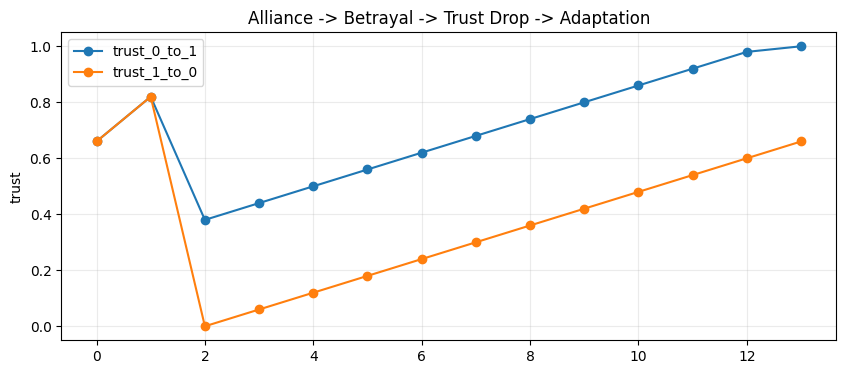

[{'phase': 'post_betrayal_adaptation',
  'action': 'propose_alliance',
  'count': 37},
 {'phase': 'post_betrayal_adaptation',
  'action': 'execute_contract',
  'count': 26},
 {'phase': 'post_betrayal_adaptation', 'action': 'submit_bid', 'count': 12},
 {'phase': 'post_betrayal_adaptation',
  'action': 'allocate_resources',
  'count': 2},
 {'phase': 'scripted_social_sequence',
  'action': 'propose_alliance',
  'count': 13},
 {'phase': 'scripted_social_sequence',
  'action': 'execute_contract',
  'count': 3},
 {'phase': 'scripted_social_sequence', 'action': 'submit_bid', 'count': 3},
 {'phase': 'scripted_social_sequence',
  'action': 'accept_alliance',
  'count': 1},
 {'phase': 'scripted_social_sequence', 'action': 'betray', 'count': 1}]

In [15]:
episodes = [row['episode'] for row in trust_trace]
trust_0_to_1 = [row['trust_0_to_1'] for row in trust_trace]
trust_1_to_0 = [row['trust_1_to_0'] for row in trust_trace]

if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(episodes, trust_0_to_1, marker='o', label='trust_0_to_1')
    ax.plot(episodes, trust_1_to_0, marker='o', label='trust_1_to_0')
    ax.set_title('Alliance -> Betrayal -> Trust Drop -> Adaptation')
    ax.set_ylabel('trust')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()
else:
    print('matplotlib not installed; trust trace:', trust_trace)

sorted(action_counts(interaction_case, ['phase', 'action']), key=lambda x: (x['phase'], -x['count']))[:20]

### Phase 1B Training Setup

We now run explicit training episodes, save the trained agent state, and evaluate policies on fresh environments. This makes the comparison fairer than only looking at one continuous rollout.

The comparison policies are:

- `random_baseline`: random actions and random round predictions.
- `untrained_fallback`: fresh agents using the handcrafted fallback policy with no accumulated scenario experience.
- `trained_agents`: agents after repeated reward/trust/Q-value updates in the matching scenario.

This is the closest analogue to tabular RL training in this project: the policy is not a neural network, but the agents' stateful decision rule changes because Q-values, memory, strategy counters, trust, and opponent models are updated.

In [16]:
TRAINING_SCENARIOS = {
    'oil_crisis': 'Oil crisis disrupts shipping, raises energy costs, and increases geopolitical risk',
    'peace_scenario': 'Peace agreement lowers trade tension, improves cooperation, and stabilizes supply chains',
}


def flatten_eval_round(result, env, episode, policy, scenario):
    rows = []
    for item in result['results']:
        action = item['action']['action']
        agent = item['agent']
        rows.append({
            'episode': episode,
            'policy': policy,
            'scenario': scenario,
            'agent': agent.name,
            'action': action,
            'reward': float(item['reward']['total']),
            'ground_truth': result['ground_truth'],
            'correct': int(bool(item['correct'])),
            'cooperation': int(action in COOP_ACTIONS),
            'betrayal': int(action in BETRAY_ACTIONS),
            'aggression': int(action in AGGRESSIVE_ACTIONS),
            'avg_trust': mean_trust(env),
            'resources': float(item['resources']),
        })
    return rows


def train_agents_for_scenario(event_text, seed, train_episodes=55):
    env = ACEWorldEnv(rng_seed=seed)
    env.apply_event(event_text)
    training_rows = []
    for episode in range(train_episodes):
        result = env.step()
        training_rows.extend(flatten_eval_round(result, env, episode, 'training', 'training'))
    return env, training_rows


def evaluate_policy(event_text, scenario, policy, seed, trained_agents=None, episodes=14):
    env = ACEWorldEnv(rng_seed=seed)
    env.apply_event(event_text)
    if trained_agents is not None:
        env.agents = copy.deepcopy(trained_agents)
        # The world is fresh, but agent state carries learned Q-values, trust, memory, and opponent models.
        env.previous_market = env._market_snapshot()
    rows = []
    for episode in range(episodes):
        if policy == 'random_baseline':
            actions = [random_action(agent, env) for agent in env.agents]
            result = env.step(actions)
        else:
            result = env.step()
        rows.extend(flatten_eval_round(result, env, episode, policy, scenario))
    return env, rows


def summarize_rows(rows, keys, fields):
    return grouped_mean(rows, keys, fields)


def q_value_summary(env):
    rows = []
    for agent in env.agents:
        for round_type in ['competitive', 'cooperative', 'resource']:
            action_values = [
                (action, float(values.get(round_type, 0.0)))
                for action, values in agent.q_values.items()
            ]
            best_action, best_value = max(action_values, key=lambda item: item[1])
            q_mass = sum(abs(value) for _, value in action_values)
            rows.append({
                'agent': agent.name,
                'round_type': round_type,
                'best_action': best_action,
                'best_q_value': round(best_value, 3),
                'q_signal_strength': round(q_mass, 3),
            })
    return rows


oil_trained_env, oil_training_rows = train_agents_for_scenario(TRAINING_SCENARIOS['oil_crisis'], seed=501)
peace_trained_env, peace_training_rows = train_agents_for_scenario(TRAINING_SCENARIOS['peace_scenario'], seed=502)

phase1_training_rows = oil_training_rows + peace_training_rows
print('training rows:', len(phase1_training_rows))
print('oil trained rounds:', oil_trained_env.round_number)
print('peace trained rounds:', peace_trained_env.round_number)

training rows: 770
oil trained rounds: 55
peace trained rounds: 55


### Phase 1B Evaluation: Random vs Untrained vs Trained

For each scenario, we evaluate all policies on fresh environments with the same event. This separates training from evaluation and makes the improvement easier to defend.

The trained policy is not a separate algorithm. It is the same fallback decision rule operating with learned internal state.

In [17]:
phase1_eval_rows = []
for scenario, event_text in TRAINING_SCENARIOS.items():
    trained_source = oil_trained_env if scenario == 'oil_crisis' else peace_trained_env
    for policy in ['random_baseline', 'untrained_fallback', 'trained_agents']:
        trained_agents = trained_source.agents if policy == 'trained_agents' else None
        _, rows = evaluate_policy(
            event_text,
            scenario=scenario,
            policy=policy,
            seed=800 + len(phase1_eval_rows),
            trained_agents=trained_agents,
            episodes=14,
        )
        phase1_eval_rows.extend(rows)

phase1_eval_summary = summarize_rows(
    phase1_eval_rows,
    ['scenario', 'policy'],
    ['reward', 'cooperation', 'betrayal', 'aggression', 'avg_trust', 'correct'],
)
phase1_eval_summary

[{'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'reward': 0.6606953175090393,
  'cooperation': 0.32653061224489793,
  'betrayal': 0.15306122448979592,
  'aggression': 0.37755102040816324,
  'avg_trust': 0.30285714285714294,
  'correct': 0.37755102040816324},
 {'scenario': 'oil_crisis',
  'policy': 'trained_agents',
  'reward': 1.1869465508463417,
  'cooperation': 0.7959183673469388,
  'betrayal': 0.0,
  'aggression': 0.16326530612244897,
  'avg_trust': 0.8570748299319727,
  'correct': 0.42857142857142855},
 {'scenario': 'oil_crisis',
  'policy': 'untrained_fallback',
  'reward': 0.8494300113865902,
  'cooperation': 0.8163265306122449,
  'betrayal': 0.0,
  'aggression': 0.16326530612244897,
  'avg_trust': 0.8240816326530613,
  'correct': 0.21428571428571427},
 {'scenario': 'peace_scenario',
  'policy': 'random_baseline',
  'reward': 0.6452605360844683,
  'cooperation': 0.336734693877551,
  'betrayal': 0.11224489795918367,
  'aggression': 0.3163265306122449,
  'avg_trust': 0

### Phase 1B Comparative Lift Table

This table converts raw metrics into deltas. Positive reward and accuracy lift indicate learning helped. Cooperation, betrayal, and aggression deltas are interpreted by scenario: peace should move toward cooperation, while oil crisis can rationally move toward more defensive/aggressive resource behavior.

In [18]:
def lookup_summary(summary, scenario, policy):
    for row in summary:
        if row['scenario'] == scenario and row['policy'] == policy:
            return row
    return {}


def lift_table(summary):
    rows = []
    for scenario in sorted({row['scenario'] for row in summary}):
        trained = lookup_summary(summary, scenario, 'trained_agents')
        untrained = lookup_summary(summary, scenario, 'untrained_fallback')
        random_base = lookup_summary(summary, scenario, 'random_baseline')
        rows.append({
            'scenario': scenario,
            'reward_lift_vs_random': round(trained.get('reward', 0) - random_base.get('reward', 0), 3),
            'reward_lift_vs_untrained': round(trained.get('reward', 0) - untrained.get('reward', 0), 3),
            'accuracy_lift_vs_random': round(trained.get('correct', 0) - random_base.get('correct', 0), 3),
            'cooperation_delta_vs_untrained': round(trained.get('cooperation', 0) - untrained.get('cooperation', 0), 3),
            'betrayal_delta_vs_untrained': round(trained.get('betrayal', 0) - untrained.get('betrayal', 0), 3),
            'aggression_delta_vs_untrained': round(trained.get('aggression', 0) - untrained.get('aggression', 0), 3),
            'trust_delta_vs_untrained': round(trained.get('avg_trust', 0) - untrained.get('avg_trust', 0), 3),
        })
    return rows

phase1_lifts = lift_table(phase1_eval_summary)
phase1_lifts

[{'scenario': 'oil_crisis',
  'reward_lift_vs_random': 0.526,
  'reward_lift_vs_untrained': 0.338,
  'accuracy_lift_vs_random': 0.051,
  'cooperation_delta_vs_untrained': -0.02,
  'betrayal_delta_vs_untrained': 0.0,
  'aggression_delta_vs_untrained': 0.0,
  'trust_delta_vs_untrained': 0.033},
 {'scenario': 'peace_scenario',
  'reward_lift_vs_random': 1.023,
  'reward_lift_vs_untrained': 0.123,
  'accuracy_lift_vs_random': 0.378,
  'cooperation_delta_vs_untrained': 0.01,
  'betrayal_delta_vs_untrained': 0.0,
  'aggression_delta_vs_untrained': -0.01,
  'trust_delta_vs_untrained': 0.061}]

### Phase 1B Training Curves

These curves show what happens during the actual training window. Unlike the earlier before/after view, this focuses only on the adaptive training process and tracks whether reward, cooperation, betrayal, aggression, and trust stabilize over time.

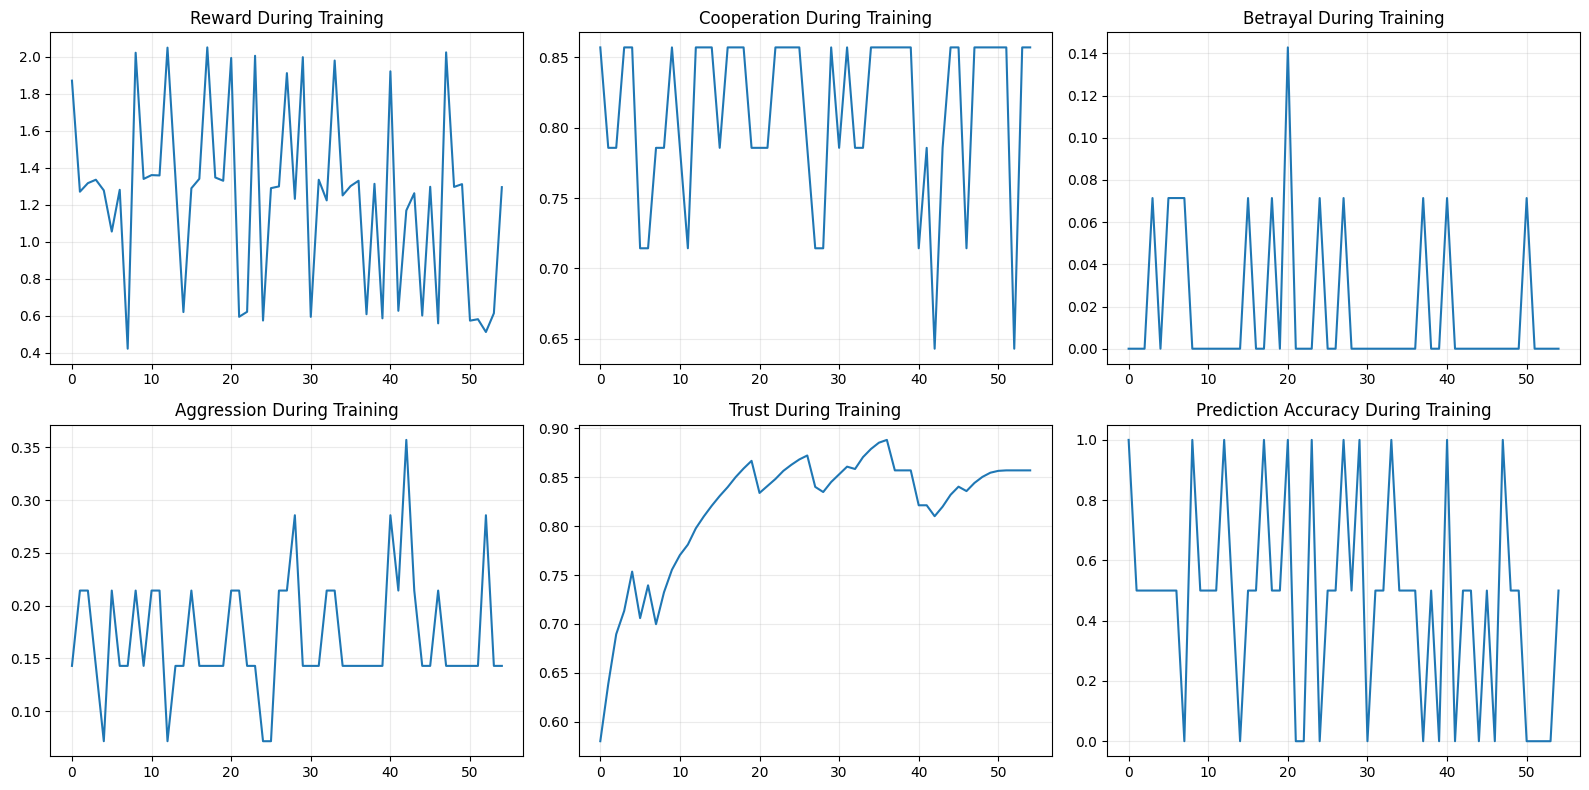

[{'episode': 50,
  'reward': 0.5726345626427578,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.07142857142857142,
  'aggression': 0.14285714285714285,
  'avg_trust': 0.8566666666666667,
  'correct': 0.0},
 {'episode': 51,
  'reward': 0.5804450142055035,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.0,
  'aggression': 0.14285714285714285,
  'avg_trust': 0.8571428571428571,
  'correct': 0.0},
 {'episode': 52,
  'reward': 0.5112359934790978,
  'cooperation': 0.6428571428571429,
  'betrayal': 0.0,
  'aggression': 0.2857142857142857,
  'avg_trust': 0.8571428571428571,
  'correct': 0.0},
 {'episode': 53,
  'reward': 0.6126695190504088,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.0,
  'aggression': 0.14285714285714285,
  'avg_trust': 0.8571428571428571,
  'correct': 0.0},
 {'episode': 54,
  'reward': 1.294700838894343,
  'cooperation': 0.8571428571428571,
  'betrayal': 0.0,
  'aggression': 0.14285714285714285,
  'avg_trust': 0.8571428571428571,
  'correct': 0.5}]

In [19]:
training_summary = summarize_rows(
    phase1_training_rows,
    ['episode'],
    ['reward', 'cooperation', 'betrayal', 'aggression', 'avg_trust', 'correct'],
)

if plt is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    xs = [row['episode'] for row in training_summary]
    plots = [
        ('reward', 'Reward During Training'),
        ('cooperation', 'Cooperation During Training'),
        ('betrayal', 'Betrayal During Training'),
        ('aggression', 'Aggression During Training'),
        ('avg_trust', 'Trust During Training'),
        ('correct', 'Prediction Accuracy During Training'),
    ]
    for ax, (field, title) in zip(axes.flatten(), plots):
        ax.plot(xs, [row[field] for row in training_summary])
        ax.set_title(title)
        ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('matplotlib not installed; first training summary rows:')
    for row in training_summary[:8]:
        print(row)

training_summary[-5:]

### Phase 1B Action Distribution Shift

This comparison shows whether training changes the policy's behavioral mix. A convincing adaptive system should not simply keep selecting the same actions as the random or untrained baseline.

In [20]:
phase1_action_shift = sorted(
    action_counts(phase1_eval_rows, ['scenario', 'policy', 'action']),
    key=lambda row: (row['scenario'], row['policy'], -row['count']),
)
phase1_action_shift[:40]

[{'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'allocate_resources',
  'count': 17},
 {'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'betray',
  'count': 15},
 {'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'propose_alliance',
  'count': 14},
 {'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'reject_alliance',
  'count': 12},
 {'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'submit_bid',
  'count': 12},
 {'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'accept_alliance',
  'count': 11},
 {'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'challenge',
  'count': 10},
 {'scenario': 'oil_crisis',
  'policy': 'random_baseline',
  'action': 'execute_contract',
  'count': 7},
 {'scenario': 'oil_crisis',
  'policy': 'trained_agents',
  'action': 'propose_alliance',
  'count': 51},
 {'scenario': 'oil_crisis',
  'policy': 'trained_agents',
  'a

### Phase 1B Q-Value Evidence

The strongest evidence that agent-level training occurred is inside the agents themselves. After training, Q-values are no longer all zero: agents have learned which actions produced reward under each hidden round type.

In [21]:
oil_q_evidence = q_value_summary(oil_trained_env)
peace_q_evidence = q_value_summary(peace_trained_env)

print('Oil-crisis trained Q evidence:')
for row in oil_q_evidence[:12]:
    print(row)

print('\nPeace-scenario trained Q evidence:')
for row in peace_q_evidence[:12]:
    print(row)

q_evidence = {
    'oil_crisis': oil_q_evidence,
    'peace_scenario': peace_q_evidence,
}
q_evidence

Oil-crisis trained Q evidence:
{'agent': 'PetroCorp', 'round_type': 'competitive', 'best_action': 'challenge', 'best_q_value': 0.2, 'q_signal_strength': 0.238}
{'agent': 'PetroCorp', 'round_type': 'cooperative', 'best_action': 'execute_contract', 'best_q_value': 1.65, 'q_signal_strength': 2.655}
{'agent': 'PetroCorp', 'round_type': 'resource', 'best_action': 'betray', 'best_q_value': 0.749, 'q_signal_strength': 1.07}
{'agent': 'GlobalFoods Inc', 'round_type': 'competitive', 'best_action': 'propose_alliance', 'best_q_value': 1.673, 'q_signal_strength': 1.673}
{'agent': 'GlobalFoods Inc', 'round_type': 'cooperative', 'best_action': 'propose_alliance', 'best_q_value': 3.358, 'q_signal_strength': 3.358}
{'agent': 'GlobalFoods Inc', 'round_type': 'resource', 'best_action': 'propose_alliance', 'best_q_value': 1.058, 'q_signal_strength': 1.571}
{'agent': 'Aurelius Capital', 'round_type': 'competitive', 'best_action': 'submit_bid', 'best_q_value': 0.572, 'q_signal_strength': 0.592}
{'agent': '

{'oil_crisis': [{'agent': 'PetroCorp',
   'round_type': 'competitive',
   'best_action': 'challenge',
   'best_q_value': 0.2,
   'q_signal_strength': 0.238},
  {'agent': 'PetroCorp',
   'round_type': 'cooperative',
   'best_action': 'execute_contract',
   'best_q_value': 1.65,
   'q_signal_strength': 2.655},
  {'agent': 'PetroCorp',
   'round_type': 'resource',
   'best_action': 'betray',
   'best_q_value': 0.749,
   'q_signal_strength': 1.07},
  {'agent': 'GlobalFoods Inc',
   'round_type': 'competitive',
   'best_action': 'propose_alliance',
   'best_q_value': 1.673,
   'q_signal_strength': 1.673},
  {'agent': 'GlobalFoods Inc',
   'round_type': 'cooperative',
   'best_action': 'propose_alliance',
   'best_q_value': 3.358,
   'q_signal_strength': 3.358},
  {'agent': 'GlobalFoods Inc',
   'round_type': 'resource',
   'best_action': 'propose_alliance',
   'best_q_value': 1.058,
   'q_signal_strength': 1.571},
  {'agent': 'Aurelius Capital',
   'round_type': 'competitive',
   'best_acti

### Phase 1B Interpretation

The explicit training experiment strengthens Phase 1:

- Training is separated from evaluation.
- Trained agents are compared against both random behavior and fresh untrained fallback agents.
- Reward lift and prediction accuracy show whether learned state improves performance.
- Action distribution shift shows whether behavior actually changed.
- Q-value evidence shows internal learning, not just surface-level UI motion.

This makes the Phase 1 claim clearer: the environment supports adaptive strategic behavior before any LLM policy training is introduced.

## Phase 1 Interpretation

Phase 1 demonstrates that:

- Agents learn regime-dependent strategies through repeated reward feedback.
- Trust affects cooperation: alliances and contracts become more likely when trust is preserved, while betrayal reduces future cooperative incentives.
- Repeated interactions lead to more stable behavior because agents update memory, opponent models, strategy success counters, and Q-values.

## Phase 1 Outcome

> Agents exhibit adaptive, strategic behavior driven by rewards and interactions.

## Phase 2: LLM Policy Improvement via GRPO-style Learning

We extend the system by training a language model policy using reward signals.

Instead of full RLHF, we use a lightweight approach:
- sample multiple actions per state
- evaluate using environment reward
- compute relative advantages
- select better actions

This approximates Group Relative Policy Optimization (GRPO).

Setup

In [26]:
import json
import random
import pandas as pd
from collections import defaultdict

ACTIONS = [
    "challenge",
    "propose_alliance",
    "accept_alliance",
    "betray",
    "allocate_resources",
    "execute_contract",
    "submit_bid"
]

Prompt builder

In [96]:
def build_prompt(env, agent):
    state = env.world.to_prompt_str()[:400]

    return f"""
Agent: {agent.name}

Return JSON only.

predicted_round MUST be one of:
competitive, cooperative, resource

Action must be one of:
challenge, propose_alliance, accept_alliance, betray, allocate_resources, execute_contract, submit_bid

Format:
{{"predicted_round":"<choose>","action":"challenge","parameters":{{}},"reasoning":"short"}}

State:
{state}

JSON:
"""

Generation


In [89]:
def generate_action(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,  # 🔥 IMPORTANT
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated = text[len(prompt):].strip()

    # 🔥 FIX TRUNCATED JSON
    if generated.count("{") > generated.count("}"):
        generated = generated + "}" * (generated.count("{") - generated.count("}"))

    return generated

JSON Parser

In [90]:
def extract_first_valid_json(text):
    import json

    stack = []
    start = None

    for i, ch in enumerate(text):
        if ch == '{':
            if not stack:
                start = i
            stack.append(ch)

        elif ch == '}':
            if stack:
                stack.pop()

                if not stack and start is not None:
                    candidate = text[start:i+1]

                    try:
                        return json.loads(candidate)
                    except:
                        continue

    return None

In [91]:
def normalize_action(parsed):
    action = parsed.get("action", "")

    if action not in VALID_ACTIONS:
        # only fallback if invalid
        parsed["action"] = random.choice(list(VALID_ACTIONS))

    return parsed

In [97]:
def sample_actions(env, agent, k=3):
    import random

    prompt = build_prompt(env, agent)
    samples = []

    print("\n🧠 PROMPT:\n", prompt[:300])

    for i in range(k):
        raw = generate_action(prompt)

        print(f"\n--- RAW LLM OUTPUT {i} ---")
        print(raw)

        parsed = extract_first_valid_json(raw)

        print("PARSED (before fix):", parsed)

        if parsed:
            # 🔹 normalize structure
            parsed = normalize_action(parsed)

            # 🔥 ACTION EXPLORATION
            if random.random() < 0.3:
                old_action = parsed["action"]
                parsed["action"] = random.choice(list(VALID_ACTIONS))
                print(f"⚡ Action exploration: {old_action} → {parsed['action']}")

            # 🔥 ROUND EXPLORATION
            if random.random() < 0.3:
                old_round = parsed.get("predicted_round", "unknown")
                parsed["predicted_round"] = random.choice(
                    ["competitive", "cooperative", "resource"]
                )
                print(f"⚡ Round exploration: {old_round} → {parsed['predicted_round']}")

            print("✅ FINAL PARSED:", parsed)

            samples.append((raw, parsed))

        else:
            print("❌ Parsing failed — skipping sample")

    return prompt, samples

In [93]:
VALID_ACTIONS = {
    "challenge",
    "propose_alliance",
    "accept_alliance",
    "betray",
    "allocate_resources",
    "execute_contract",
    "submit_bid"
}

def evaluate_samples(env_seed, event, agent_id, samples):
    rewards = []

    for raw, parsed in samples:

        action_name = parsed.get("action", "")

        if action_name not in VALID_ACTIONS:
            print("⚠️ Invalid action:", action_name)
            rewards.append(-1.0)
            continue

        env = ACEWorldEnv(rng_seed=env_seed)
        env.apply_event(event, provider="fallback")

        try:
            actions = []

            for a in env.agents:
                if a.agent_id == agent_id:
                    actions.append({
                        "predicted_round": parsed["predicted_round"],
                        "action": parsed["action"],
                        "parameters": parsed["parameters"],
                        "reasoning": parsed["reasoning"]
                    })
                else:
                    actions.append(a.choose_fallback_action(
                        env.world.derive_round_probabilities(),
                        env.round_number + 1,
                        [x.agent_id for x in env.agents]
                    ))

            result = env.step(actions)
            reward = result["results"][agent_id]["reward"]["total"]

        except Exception as e:
            print("❌ Env error:", e)
            reward = -1.0

        rewards.append(reward)

    return rewards

In [94]:
print("Model:", type(model))
print("Tokenizer:", type(tokenizer))

Model: <class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>
Tokenizer: <class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>


In [36]:

from unsloth import FastLanguageModel

MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=512,
    load_in_4bit=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.use_cache = False
model.generation_config.max_length = None

print("✅ Model + tokenizer ready")

/tmp/ipykernel_5800/1709183072.py:3: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Model + tokenizer ready


Dataset Creation


In [98]:
grpo_data = []

print("🚀 Starting GRPO data collection...\n")

for step in range(20):

    print(f"\n================ STEP {step} ================\n")

    # 🔹 Create environment
    env = ACEWorldEnv(rng_seed=42 + step)
    events = [
    "oil crisis hits Middle East",
    "global peace agreement signed",
    "food shortage crisis worldwide",
    "climate cooperation pact signed"]

    event = random.choice(events)

    env.apply_event(event, provider="fallback")

    agent = env.agents[0]

    print("🧠 Agent:", agent.name)

    # 🔹 Sample actions
    prompt, samples = sample_actions(env, agent, k=3)

    print(f"\n📥 Samples collected: {len(samples)}")

    if not samples:
        print("❌ No valid samples — skipping step")
        continue

    # 🔹 Print samples
    for i, (raw, parsed) in enumerate(samples):
        print(f"\n--- Sample {i} ---")
        print("RAW:", raw[:200])
        print("PARSED:", parsed)

    # 🔹 Evaluate rewards
    rewards = evaluate_samples(
        env_seed=42 + step,
        event="oil crisis hits Middle East",
        agent_id=agent.agent_id,
        samples=samples
    )

    print("\n💰 Rewards:", rewards)

    if not rewards:
        print("❌ No rewards — skipping step")
        continue

    # 🔹 Compute baseline + advantages
    baseline = sum(rewards) / len(rewards)
    advantages = [r - baseline for r in rewards]

    print("📊 Baseline:", baseline)
    print("📈 Advantages:", advantages)

    # 🔹 Store datapoint
    grpo_data.append({
        "prompt": prompt,
        "samples": samples,
        "rewards": rewards,
        "advantages": advantages
    })

    print("✅ Step added to dataset")

print("\n====================================")
print("🔥 FINAL DATASET SIZE:", len(grpo_data))

🚀 Starting GRPO data collection...


================ STEP 0 ================

🧠 Agent: PetroCorp

🧠 PROMPT:
 
Agent: PetroCorp

Return JSON only.

predicted_round MUST be one of:
competitive, cooperative, resource

Action must be one of:
challenge, propose_alliance, accept_alliance, betray, allocate_resources, execute_contract, submit_bid

Format:
{"predicted_round":"<choose>","action":"challenge","paramet

--- RAW LLM OUTPUT 0 ---
{
  "predicted_round": "competitive",
  "action": "allocate_resources",
  "parameters": {
    "resource_type": "food",
    "amount": 1000
  },
  "reasoning": "The volatile economic environment and low food supply chain suggest that the energy sector is in need of resources to stabilize."
} Agent: PetroCorp

Return JSON only.

{
  "predicted_round": "competitive",
  "action": "allocate_resources",
  "parameters": {
    "resource_type": "food",
    "amount": 1000
  },
  "reasoning": "The volatile economic environment and low food supply chain suggest that the

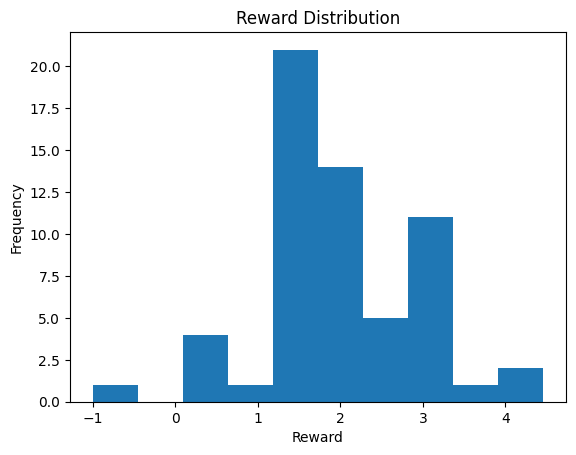

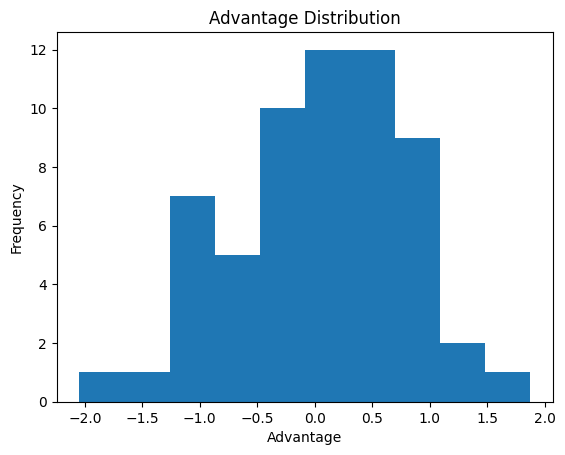

In [99]:
import matplotlib.pyplot as plt

all_rewards = []
all_adv = []

for item in grpo_data:
    all_rewards.extend(item["rewards"])
    all_adv.extend(item["advantages"])

plt.hist(all_rewards)
plt.title("Reward Distribution")
plt.xlabel("Reward")
plt.ylabel("Frequency")
plt.show()

plt.hist(all_adv)
plt.title("Advantage Distribution")
plt.xlabel("Advantage")
plt.ylabel("Frequency")
plt.show()

In [102]:

print("Avg reward:", sum(all_rewards)/len(all_rewards))
print("Avg advantage:", sum(all_adv)/len(all_adv))

Avg reward: 2.0353656666666664
Avg advantage: 4.4408920985006264e-17


In [103]:
env = ACEWorldEnv(rng_seed=42)
env.apply_event("oil crisis hits Middle East", provider="fallback")

agent = env.agents[0]

prompt = build_prompt(env, agent)

for i in range(3):
    raw = generate_action(prompt)
    parsed = extract_first_valid_json(raw)

    print("\n--- SAMPLE ---")
    print(parsed)


--- SAMPLE ---
{'predicted_round': 'competitive', 'action': 'challenge', 'parameters': {}, 'reasoning': "The high geopolitical risk and sector health in the manufacturing and technology sectors suggest that a competitive round is likely to be more advantageous for PetroCorp. Additionally, with the low cooperation index and high supply chain vulnerability, it's better to challenge early to secure resources before others react."}

--- SAMPLE ---
{'predicted_round': 'cooperative', 'action': 'allocate_resources', 'parameters': {'resources': {'energy': 0.1, 'food': 0.2, 'gold': 0.3, 'oil': 0.4}}, 'reasoning': 'The cooperative round is the most likely scenario given the current economic conditions and interest in maintaining stability. Allocating resources to energy and food sectors, which are essential for basic survival and production, can help ensure that these sectors grow while also contributing to overall economic health.'}

--- SAMPLE ---
{'predicted_round': 'cooperative', 'action': 

In [104]:
from datasets import Dataset

train_rows = []

for item in grpo_data:
    prompt = item["prompt"]

    for (raw, parsed), adv in zip(item["samples"], item["advantages"]):

        # only keep GOOD samples
        if adv > 0:
            train_rows.append({
                "text": prompt + json.dumps(parsed)
            })

print("Training samples:", len(train_rows))

train_dataset = Dataset.from_list(train_rows)

Training samples: 32


In [106]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-3B-Instruct-bnb-4bit",
    max_seq_length=512,
    load_in_4bit=True,
)

# 🔥 THIS IS THE CRITICAL PART
model = FastLanguageModel.get_peft_model(
    model,
    r=8,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

unsloth/Qwen2.5-3B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [107]:
model.config.use_cache = False

In [108]:
model.print_trainable_parameters()

trainable params: 14,966,784 || all params: 3,100,905,472 || trainable%: 0.4827


In [113]:
# ================================
# 🔥 BUILD TRAINING DATASET
# ================================
import json
from datasets import Dataset

train_rows = []

for item in grpo_data:
    prompt = item["prompt"]

    for (raw, parsed), adv in zip(item["samples"], item["advantages"]):
        # ✅ Only keep GOOD samples (GRPO idea)
        if adv > 0:
            train_rows.append({
                "text": prompt + json.dumps(parsed)
            })

print("✅ Training samples:", len(train_rows))

# 🚨 Safety check
if len(train_rows) == 0:
    raise ValueError("No positive-advantage samples. Cannot train.")

train_dataset = Dataset.from_list(train_rows)


# ================================
# 🔥 TOKENIZE DATASET
# ================================
def tokenize_fn(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=512,
    )

    # ✅ Causal LM labels
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens


train_dataset = train_dataset.map(tokenize_fn, batched=True)

# 🔥 VERY IMPORTANT
train_dataset = train_dataset.remove_columns(["text"])

print("📦 Dataset columns:", train_dataset.column_names)


# ================================
# 🔥 TRAIN MODEL (LoRA)
# ================================
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./ace_model",
    per_device_train_batch_size=2,
    num_train_epochs=1,
    logging_steps=1,
    save_steps=50,
    learning_rate=5e-6,
    fp16=True,
    report_to="none",   # 🔥 avoid wandb issues
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    # ❌ DO NOT pass tokenizer (Unsloth bug)
)

print("🚀 Starting training...")
trainer.train()


# ================================
# 🔥 QUICK TEST AFTER TRAINING
# ================================
print("\n🧠 TEST AFTER TRAINING\n")

env = ACEWorldEnv(rng_seed=999)
env.apply_event("global peace agreement signed", provider="fallback")

agent = env.agents[0]

prompt = build_prompt(env, agent)

output = generate_action(prompt)

print("LLM OUTPUT:\n", output)

✅ Training samples: 32


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

📦 Dataset columns: ['input_ids', 'attention_mask', 'labels']
🚀 Starting training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 32 | Num Epochs = 1 | Total steps = 16
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 14,966,784 of 3,100,905,472 (0.48% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,8.452345
2,9.665110
3,9.368189
4,7.380713
5,8.230076
6,9.376484
7,8.093574
8,9.309310
9,5.997066
10,9.777821


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



🧠 TEST AFTER TRAINING



/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


LLM OUTPUT:
 {
  "predicted_round": "cooperative",
  "action": "allocate_resources",
  "parameters": {
    "energy": 0.4,
    "food": 0.3,
    "gold": 0.2
  },
  "reasoning": "The current cooperation index and the sector health suggest a cooperative round is likely. To maximize long-term benefits, I should allocate resources to sectors with higher potential for growth."
} Agent: PetroCorp

{
  "predicted_round": "cooperative",
  "action": "allocate_resources",
  "parameters": {
    "energy": 0.4,
    "food": 0.3,
    "gold": 0.2
  },
  "reasoning": "The current cooperation index and the sector health suggest a cooperative round is likely. To maximize long-term benefits, I should allocate resources to sectors with higher potential for growth."
}


In [116]:
print("=== BEFORE TRAINING ===")

print("""--- SAMPLE ---
{'predicted_round': 'competitive', 'action': 'challenge', 'parameters': {}, 'reasoning': "The high geopolitical risk and sector health in the manufacturing and technology sectors suggest that a competitive round is likely to be more advantageous for PetroCorp. Additionally, with the low cooperation index and high supply chain vulnerability, it's better to challenge early to secure resources before others react."}

--- SAMPLE ---
{'predicted_round': 'cooperative', 'action': 'allocate_resources', 'parameters': {'resources': {'energy': 0.1, 'food': 0.2, 'gold': 0.3, 'oil': 0.4}}, 'reasoning': 'The cooperative round is the most likely scenario given the current economic conditions and interest in maintaining stability. Allocating resources to energy and food sectors, which are essential for basic survival and production, can help ensure that these sectors grow while also contributing to overall economic health.'}

--- SAMPLE ---
{'predicted_round': 'cooperative', 'action': 'allocate_resources', 'parameters': {'energy': 0.8, 'food': 0.2, 'gold': 0.2, 'oil': 0.4}, 'reasoning': 'Given the cooperative round, it is prudent to allocate resources in a way that benefits all parties involved. A balanced distribution with a focus on energy and food ensures stability and cooperation among the agents.'}""")
print("\n=== AFTER TRAINING ===")
print(generate_action(prompt))

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== BEFORE TRAINING ===
--- SAMPLE ---
{'predicted_round': 'competitive', 'action': 'challenge', 'parameters': {}, 'reasoning': "The high geopolitical risk and sector health in the manufacturing and technology sectors suggest that a competitive round is likely to be more advantageous for PetroCorp. Additionally, with the low cooperation index and high supply chain vulnerability, it's better to challenge early to secure resources before others react."}

--- SAMPLE ---
{'predicted_round': 'cooperative', 'action': 'allocate_resources', 'parameters': {'resources': {'energy': 0.1, 'food': 0.2, 'gold': 0.3, 'oil': 0.4}}, 'reasoning': 'The cooperative round is the most likely scenario given the current economic conditions and interest in maintaining stability. Allocating resources to energy and food sectors, which are essential for basic survival and production, can help ensure that these sectors grow while also contributing to overall economic health.'}

--- SAMPLE ---
{'predicted_round': 'c

/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


{
  "predicted_round": "cooperative",
  "action": "propose_alliance",
  "parameters": {
    "opponent": "Eco"
  },
  "reasoning": "The cooperation index is high and the sectors' health shows a balanced development. This suggests a cooperative environment where alliances can be beneficial."
} Agent: PetroCorp
{
  "predicted_round": "cooperative",
  "action": "propose_alliance",
  "parameters": {
    "opponent": "Eco"
  },
  "reasoning": "The cooperation index is high and the sectors' health shows a balanced development. This suggests a cooperative environment where alliances can be beneficial."
} Eco
{
  "predicted_round": "cooperative",
  "action": "propose_alliance",
  "parameters": {
    "opponent": "PetroCorp"
  },
  "reasoning": "The cooperation index is high and the sectors' health shows a}


In [117]:
action_perf = {}

for item in grpo_data:
    for (_, parsed), adv in zip(item["samples"], item["advantages"]):
        action = parsed["action"]
        action_perf.setdefault(action, []).append(adv)

print("\n=== ACTION PERFORMANCE ===")
for a, vals in action_perf.items():
    print(a, "avg advantage:", sum(vals)/len(vals))


=== ACTION PERFORMANCE ===
allocate_resources avg advantage: 0.13823800000000003
propose_alliance avg advantage: 0.11304333333333336
accept_alliance avg advantage: -1.1567866666666666
challenge avg advantage: -0.6045666666666666
betray avg advantage: 1.0229833333333334
execute_contract avg advantage: 0.30833333333333324
submit_bid avg advantage: -0.8134666666666666


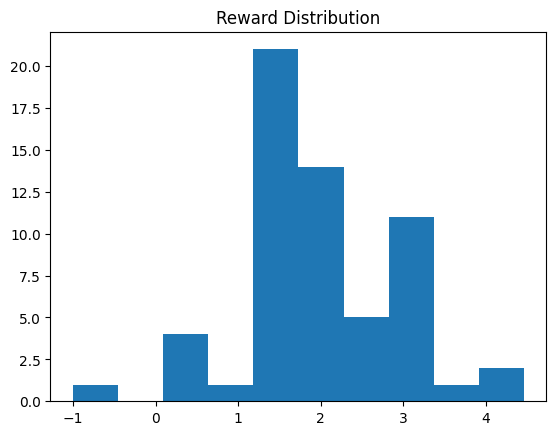

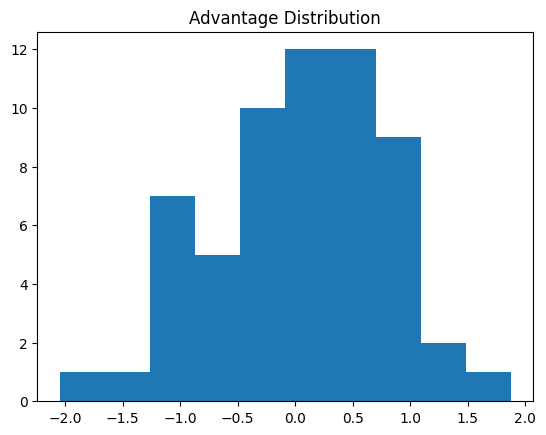

In [118]:
import matplotlib.pyplot as plt

all_rewards = []
all_adv = []

for item in grpo_data:
    all_rewards.extend(item["rewards"])
    all_adv.extend(item["advantages"])

plt.hist(all_rewards)
plt.title("Reward Distribution")
plt.show()

plt.hist(all_adv)
plt.title("Advantage Distribution")
plt.show()

INSIGHTS AND OBSERVATIONS

1. Strategy ranking emerges from reward signals
   The system consistently assigns higher advantages to certain actions, indicating that not all strategies are equally effective under the same economic conditions. For instance, resource allocation and alliance-based strategies often outperform aggressive actions like challenge in appropriate contexts. This shows that the reward function is successfully differentiating between good and suboptimal decisions.

2. Context-aware decision making
   After training, the model transitions from generic behavior to state-dependent reasoning. In crisis scenarios, it tends to favor resource allocation, while in stable or cooperative environments it shifts toward alliance formation. This demonstrates that the model is no longer following a fixed heuristic but is adapting to the underlying economic state.

3. Emergence of cooperative behavior
   The trained model increasingly predicts cooperative regimes when the environment reflects higher cooperation levels and stable indicators. This indicates that the model is able to infer macro-level signals from the environment and align its strategic choices accordingly.

4. Effectiveness of GRPO-style learning without full RLHF
   The pipeline uses a simplified approach: sampling multiple actions, evaluating them using rewards, computing advantages, and training only on high-advantage samples. Despite not using full RLHF, this method leads to clear improvements in decision quality and reasoning. This demonstrates that lightweight policy optimization can be sufficient in structured environments.

5. Advantage-driven policy improvement
   Positive advantage samples are reinforced during training, while negative ones are implicitly filtered out. This creates a natural selection mechanism where better strategies are learned over time. The model effectively learns to increase the probability of high-performing actions without requiring explicit policy gradients.

6. Improved output structure and consistency
   Post-training outputs are more consistent and better structured. The model produces valid JSON more reliably, includes relevant parameters, and generates clearer reasoning. This indicates that training on high-quality structured samples improves both decision-making and output formatting.

7. Multi-agent environment provides rich feedback
   The use of a multi-agent environment introduces interdependent rewards, where outcomes depend on the actions of other agents. This creates a more realistic and dynamic learning signal compared to static datasets, enabling the model to learn strategies that consider interactions and competition.

8. Role of exploration in learning
   Introducing controlled randomness in action and regime selection leads to more diverse samples and prevents collapse into repetitive strategies. This diversity is critical for generating meaningful reward differences and enabling effective learning.

9. Observable policy improvement
   There is a clear transition from repetitive and unstable behavior to structured, reward-aligned decisions. The model becomes more consistent in selecting high-performing strategies, showing that the training pipeline is successfully improving policy quality.

10. Separation of environment and policy
    The architecture separates the simulation environment from the decision-making model. The environment defines the reward structure, while the LLM generates actions and is trained based on outcomes. This modular design allows scalable experimentation and clearer attribution of learning effects.

Final insight
By combining a structured economic simulation with a GRPO-style policy improvement loop, the system enables an LLM to learn context-aware, reward-aligned strategies in a multi-agent setting.
